# Forecasting Network Charging Demand

Module F. The brief forecasts demand per charging station, but 462 stations across 1,320
sessions is roughly 2.8 sessions each — far too sparse to model. And because the
timestamps form a perfect hourly grid (one session every hour, established in the EDA),
the *number* of sessions per hour never changes. What does vary is the **energy** drawn,
so the target here is `energy_kwh` aggregated to the hour across the whole network.

> **Time-series forecasting**
>
> Forecasting predicts future values of a series from its own past and from other
> information available at prediction time (the calendar, the weather). The two things
> that make a series forecastable are **trend** (a persistent drift) and **seasonality**
> (a repeating daily or weekly shape). We check for both before modelling.

> **Walk-forward validation**
>
> Rows in a time series cannot be shuffled — the model must never train on data from
> after the point it is predicting. Walk-forward validation trains on an initial stretch,
> predicts the next block, then extends the training window to include that block and
> repeats. Every prediction is genuinely out-of-sample.

## Contents

* Build the hourly demand series
* Look at the series: trend and seasonality
* Autocorrelation — is there anything to exploit?
* Features: calendar and lagged demand
* Baselines: flat mean and seasonal-naive
* Gradient boosting with walk-forward validation
* Actual vs forecast
* Interpretation and caveats
* Persist the forecaster

## Build the hourly demand series

`build_hourly_demand` resamples the sessions to one row per hour from the first session
to the last, sums each hour's energy, and linearly interpolates the 66 hours whose energy
reading was missing. It then adds calendar columns and three lagged-demand features
(defined later) and drops the first 24 hours, which have no 24-hour lag.

In [1]:
import sys

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd

from evcharging.config import CLEAN_PARQUET

df = pd.read_parquet(CLEAN_PARQUET)

In [2]:
from evcharging.models.demand import build_hourly_demand

hourly = build_hourly_demand(df)
hourly.head()

,energy_kwh,hour,weekday,is_weekend,month,temperature_c,lag_1,lag_24,roll_24_mean
start_time,,,,,,,,,
2024-01-02 00:00:00,27.604385,0,1,0,1,35.977822,68.447126,60.712346,39.326623
2024-01-02 01:00:00,40.178003,1,1,0,1,21.536844,27.604385,12.339275,37.947124
2024-01-02 02:00:00,43.487751,2,1,0,1,29.872210,40.178003,19.128876,39.107071
2024-01-02 03:00:00,10.338518,3,1,0,1,5.504759,43.487751,79.457824,40.122024
2024-01-02 04:00:00,31.684485,4,1,0,1,20.378562,10.338518,19.629104,37.242053


In [3]:
print(f"{len(hourly)} hourly points, {hourly.index.min()} to {hourly.index.max()}")
hourly["energy_kwh"].describe().round(2)

1296 hourly points, 2024-01-02 00:00:00 to 2024-02-24 23:00:00


count    1296.00
mean       42.87
std        22.12
min         0.05
25%        24.87
50%        42.83
75%        61.01
max       152.24
Name: energy_kwh, dtype: float64

## Look at the series: trend and seasonality

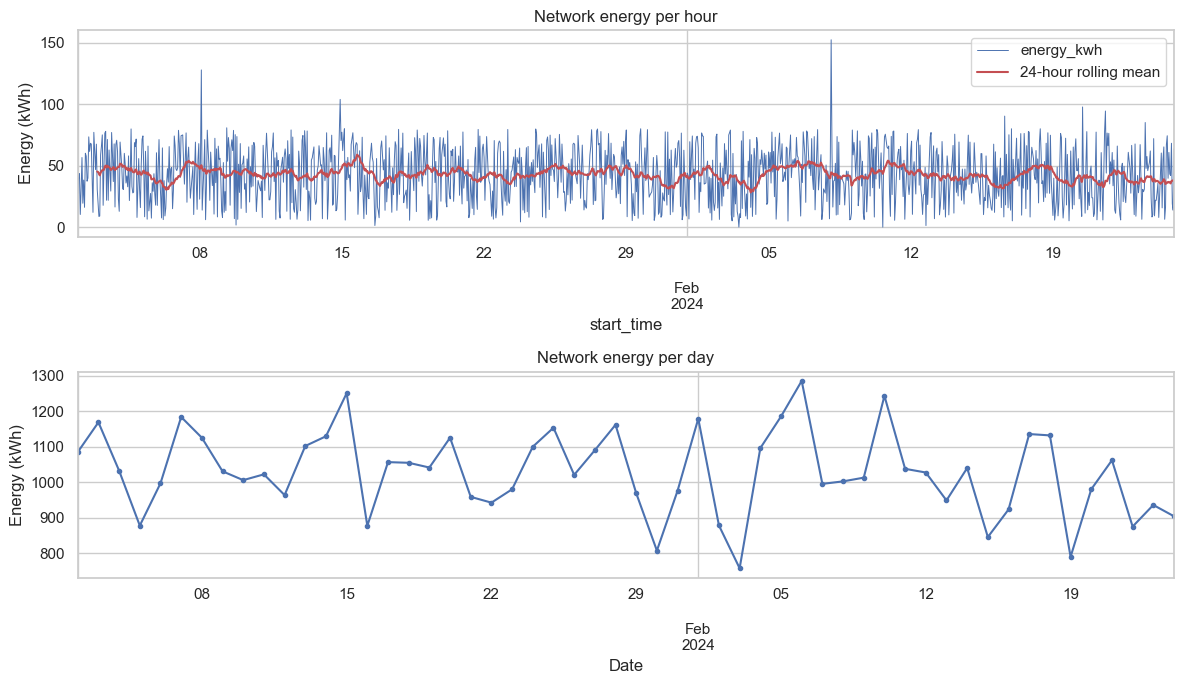

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

hourly["energy_kwh"].plot(ax=axes[0], lw=0.7)
hourly["energy_kwh"].rolling(24).mean().plot(ax=axes[0], color="#C44E52", lw=1.5,
                                             label="24-hour rolling mean")
axes[0].set_title("Network energy per hour")
axes[0].set_ylabel("Energy (kWh)")
axes[0].legend()

daily = hourly["energy_kwh"].resample("D").sum()
daily.plot(ax=axes[1], marker="o", ms=3)
axes[1].set_title("Network energy per day")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Energy (kWh)")

plt.tight_layout()
plt.show()

**Observations**

* The hourly series is noise around a flat level. The 24-hour rolling mean is almost a
  straight horizontal line — **no trend**.
* Daily totals hover around a constant (24 sessions × ~43 kWh) with modest scatter and no
  weekly pattern.
* Whatever a model learns here, it will not be a trend or a growth rate.

### The average day and the average week

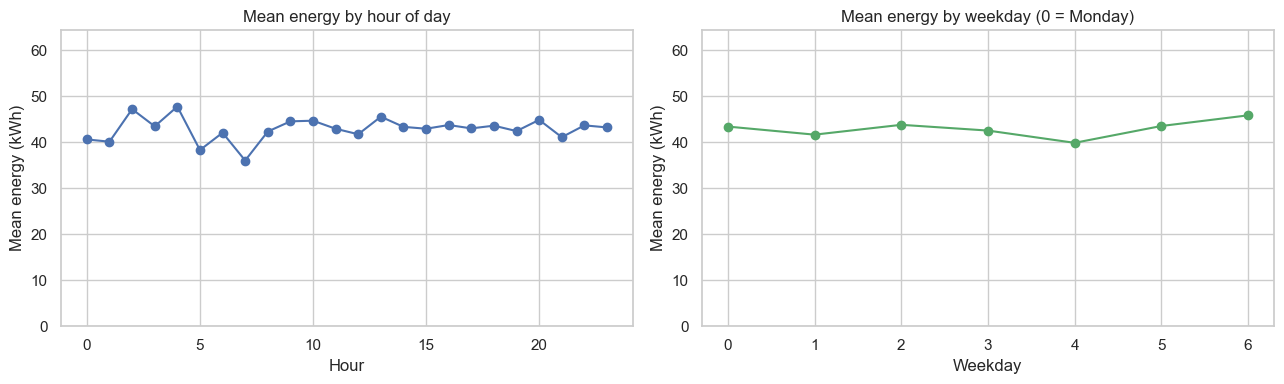

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

hourly.groupby("hour")["energy_kwh"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Mean energy by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean energy (kWh)")
axes[0].set_ylim(0, hourly["energy_kwh"].mean() * 1.5)

hourly.groupby("weekday")["energy_kwh"].mean().plot(ax=axes[1], marker="o", color="#55A868")
axes[1].set_title("Mean energy by weekday (0 = Monday)")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Mean energy (kWh)")
axes[1].set_ylim(0, hourly["energy_kwh"].mean() * 1.5)

plt.tight_layout()
plt.show()

**Observations**

* The hour-of-day profile is flat within noise — no morning or evening peak, unlike a
  real charging network.
* The weekday profile is flat too. There is **no seasonality** at either the daily or the
  weekly scale.

## Autocorrelation — is there anything to exploit?

> **Autocorrelation**
>
> The autocorrelation at lag *k* is the correlation between the series and a copy of
> itself shifted by *k* steps. A forecastable series shows high autocorrelation at small
> lags (persistence) and spikes at seasonal lags (24 h, 168 h). Values near zero mean
> each point is independent of its neighbours — nothing to forecast from the past.

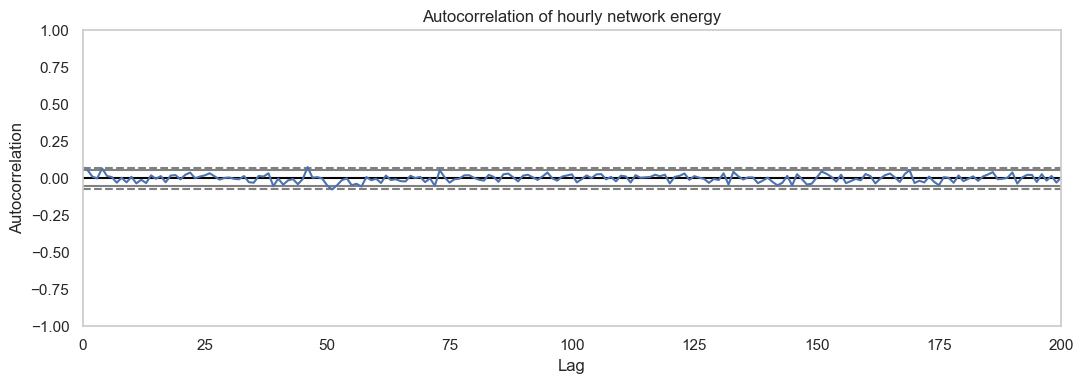

autocorrelation at lag   1h: +0.057
autocorrelation at lag   2h: +0.012
autocorrelation at lag  24h: +0.012
autocorrelation at lag 168h: +0.033


In [6]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(11, 4))
autocorrelation_plot(hourly["energy_kwh"])
plt.title("Autocorrelation of hourly network energy")
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

for lag in [1, 2, 24, 168]:
    r = hourly["energy_kwh"].autocorr(lag)
    print(f"autocorrelation at lag {lag:>3}h: {r:+.3f}")

**Observations**

* Every autocorrelation sits inside the confidence band around zero, including at the
  daily (24 h) and weekly (168 h) lags.
* The series is essentially white noise. A lag-based model has no real signal to use; we
  still build one because on a real series it would, and the pipeline is the deliverable.

## Features: calendar and lagged demand

The model gets eight features:

* **Calendar** — `hour`, `weekday`, `is_weekend`, `month`, and the hour's
  `temperature_c`.
* **Lagged demand** — `lag_1` (energy one hour ago), `lag_24` (energy at the same hour
  yesterday), `roll_24_mean` (mean energy over the previous 24 hours). These are the
  standard way to let a plain regressor use the series' own history.

All lags use only past values, so they are safe to compute up front.

In [7]:
from evcharging.models.demand import CALENDAR_FEATURES, DEMAND_FEATURES, LAG_FEATURES

print("calendar:", CALENDAR_FEATURES)
print("lags    :", LAG_FEATURES)
hourly[DEMAND_FEATURES].head()

calendar: ['hour', 'weekday', 'is_weekend', 'month', 'temperature_c']
lags    : ['lag_1', 'lag_24', 'roll_24_mean']


,hour,weekday,is_weekend,month,temperature_c,lag_1,lag_24,roll_24_mean
start_time,,,,,,,,
2024-01-02 00:00:00,0,1,0,1,35.977822,68.447126,60.712346,39.326623
2024-01-02 01:00:00,1,1,0,1,21.536844,27.604385,12.339275,37.947124
2024-01-02 02:00:00,2,1,0,1,29.872210,40.178003,19.128876,39.107071
2024-01-02 03:00:00,3,1,0,1,5.504759,43.487751,79.457824,40.122024
2024-01-02 04:00:00,4,1,0,1,20.378562,10.338518,19.629104,37.242053


## Baselines: flat mean and seasonal-naive

> **Seasonal-naive forecast**
>
> The seasonal-naive forecast for an hour is simply the value from one full season ago —
> here, 24 hours earlier (`lag_24`). It is the standard baseline for any series with a
> daily cycle: a model that cannot beat it has not learned the cycle. The other baseline
> is the flat historical mean.

In [8]:
from evcharging.models.demand import walk_forward

result = walk_forward(hourly, n_splits=5)

pd.DataFrame({
    "GradientBoosting": result.model_metrics,
    "mean baseline": result.mean_baseline_metrics,
    "seasonal-naive": result.seasonal_naive_metrics,
}).T.round(3)

,mae,rmse,r2
GradientBoosting,19.584,23.294,-0.114
mean baseline,18.708,22.109,-0.004
seasonal-naive,25.190,31.156,-0.993


**Observations**

* The **seasonal-naive** forecast is the *worst* of the three (MAE ≈ 25 kWh). Repeating
  yesterday's value adds noise because there is no daily cycle to repeat.
* The **flat mean** is the best (MAE ≈ 19 kWh) — with no structure, the long-run average
  is the best point forecast.
* **Gradient boosting** lands between the two (MAE ≈ 20 kWh). It beats seasonal-naive
  comfortably but cannot beat the mean, because its lag features are noise.

## Gradient boosting with walk-forward validation

> **Gradient boosting**
>
> Gradient boosting builds shallow regression trees one at a time, each fitted to the
> errors the current ensemble still makes, scaled down by a small `learning_rate`. It is
> a strong default for tabular data. Here it is used as the forecasting regressor over
> the calendar and lag features.

The walk-forward loop splits the series into six equal blocks and, for each of the last
five, trains on everything before it and predicts it.

In [9]:
print(f"walk-forward: {result.n_splits} expanding folds, "
      f"{len(result.predictions)} out-of-sample hours scored")
result.predictions.head()

walk-forward: 5 expanding folds, 1080 out-of-sample hours scored


,actual,model,seasonal_naive
start_time,,,
2024-01-11 00:00:00,29.582840,47.453698,67.922832
2024-01-11 01:00:00,37.509777,44.768650,15.273667
2024-01-11 02:00:00,7.849722,32.793786,50.643737
2024-01-11 03:00:00,66.520764,46.202252,52.054742
2024-01-11 04:00:00,48.180694,38.085411,57.897998


## Actual vs forecast

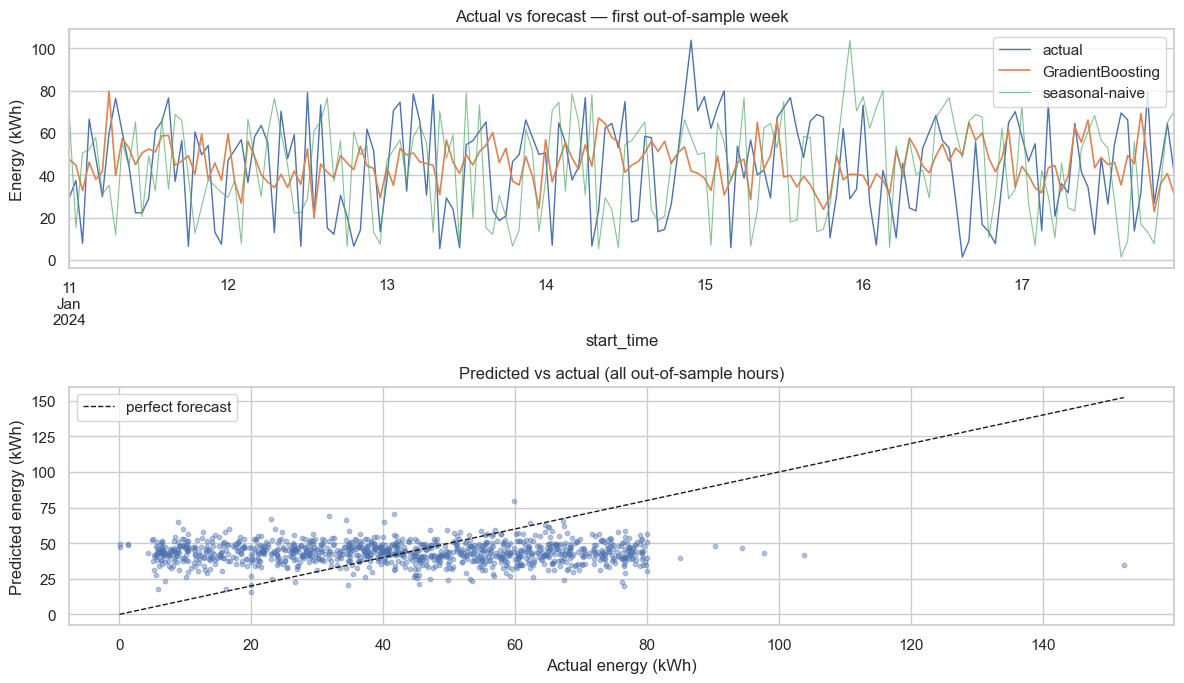

In [10]:
preds = result.predictions

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

window = preds.iloc[:168]  # first out-of-sample week
window["actual"].plot(ax=axes[0], label="actual", lw=1)
window["model"].plot(ax=axes[0], label="GradientBoosting", lw=1.2)
window["seasonal_naive"].plot(ax=axes[0], label="seasonal-naive", lw=0.8, alpha=0.7)
axes[0].set_title("Actual vs forecast — first out-of-sample week")
axes[0].set_ylabel("Energy (kWh)")
axes[0].legend()

axes[1].scatter(preds["actual"], preds["model"], s=10, alpha=0.4)
lo, hi = preds["actual"].min(), preds["actual"].max()
axes[1].plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect forecast")
axes[1].set_title("Predicted vs actual (all out-of-sample hours)")
axes[1].set_xlabel("Actual energy (kWh)")
axes[1].set_ylabel("Predicted energy (kWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Observations**

* In the time plot the model's line is a gently varying band near the mean while the
  actual series spikes around it — the model correctly declines to chase noise.
* The predicted-vs-actual scatter is a near-horizontal cloud: predictions vary far less
  than reality because there is no signal to justify larger swings.

## Interpretation and caveats

**What the model does.** It reproduces the historical mean, with tiny calendar-driven
wiggles. It beats a seasonal-naive baseline (MAE ≈ 20 vs 25 kWh) because it does not
propagate yesterday's noise, but it does not beat a flat mean.

**Why.** The hourly energy series has no trend, no daily or weekly seasonality, and
autocorrelation indistinguishable from zero. That is a property of how the dataset was
generated — each session's energy was drawn roughly independently — not of real charging
demand.

**Caveats for anyone reading the forecast:**

1. **Synthetic data.** These numbers describe the file, not a real network. On real data
   the same features (`hour`, `weekday`, lags, temperature) typically carry a strong
   daily peak.
2. **Short history.** 54 usable days is too short to see monthly effects or holidays.
3. **Network level only.** Per-station or even per-city forecasts are not supported by
   the data volume; the artifact forecasts the network total.
4. **The honest operating recommendation** is to plan against the historical hourly mean
   and its spread, and to treat the model output as "no better than that" until a real
   feed with genuine structure is connected.

**What is reusable.** The pipeline — hourly aggregation, lag construction, walk-forward
validation, baseline comparison — is exactly what a real forecasting task needs and would
surface real seasonality if it existed.

## Persist the forecaster

In [11]:
from evcharging.models.demand import train

result, hourly, final_model = train(df)
result.metrics_payload()

{'target': 'network energy_kwh per hour',
 'n_test_points': 1080,
 'walk_forward_splits': 5,
 'features': ['hour',
  'weekday',
  'is_weekend',
  'month',
  'temperature_c',
  'lag_1',
  'lag_24',
  'roll_24_mean'],
 'model': {'name': 'GradientBoostingRegressor',
  'mae': 19.5838,
  'rmse': 23.2936,
  'r2': -0.1143},
 'baseline_mean': {'mae': 18.7075, 'rmse': 22.1088, 'r2': -0.0039},
 'baseline_seasonal_naive': {'mae': 25.1898, 'rmse': 31.1555, 'r2': -0.9935},
 'model_vs_seasonal_naive_mae_ratio': 0.7774}

In [12]:
from evcharging.models.common import load_artifact

bundle = load_artifact("demand_forecaster.joblib")
# forecast the last hour from its own feature row, as a smoke test
bundle["model"].predict(hourly[bundle["features"]].tail(1))

array([50.54290143])

## Summary / Key Takeaways

* Demand is forecast at the **network level, hourly**, with `energy_kwh` as the target —
  session counts are constant on this grid and per-station data is too sparse.
* The series has **no trend and no seasonality**; hourly autocorrelation is ≈ 0.
* Walk-forward MAE: **seasonal-naive ≈ 25 kWh, gradient boosting ≈ 20 kWh, flat mean ≈
  19 kWh**. The model beats seasonal-naive but not the mean.
* The result is reported with an explicit caveats section; the pipeline is production-shaped
  and would find real structure if present.
* `demand_forecaster.joblib` stores the final model. This completes the Phase 2 model
  suite; `scripts/train_all.py` runs all five in sequence.